<div ><img src = "figs/ans_banner_1920x200.png" /></div>

# Semana 5. Sesión Sincrónica.

# Sistemas de Recomendación I

El *cuaderno* tiene como objetivo hacer una introducción a los sistemas de recomendación: cómo se construyen, qué supuestos hace cada uno y cómo se comparan entre sí.

**NO** es necesario editar el archivo o hacer una entrega. Los ejemplos contienen celdas con código ejecutable (`en gris`), que podrá modificar libremente. Esta puede ser una buena forma de aprender nuevas funcionalidades del *cuaderno*, o experimentar variaciones en los códigos de ejemplo.


# 1. ¿Qué es un sistema de recomendación?

Las preferencias de los individuos suelen seguir patrones que los sistemas de recomendación pueden aprovechar. Por ejemplo,

- Si te interesó: <div style="max-width:200px"><img src = "figs/iron_man.jpg" /></div>

- También te puede interesar: <div style="max-width:200px"><img src = "figs/thor.jpg" /></div>

- Los sistemas de recomendación encuentran patrones que son utilizados para predecir qué otros productos podrían gustarnos y generar sugerencias, de forma tal que los usuarios encuentren contenido atractivo en un gran corpus.

- Estos sistemas son muy exitosos. Según un estudio del 2013 de [McKinsey](https://www.mckinsey.com/industries/retail/our-insights/how-retailers-can-keep-up-with-consumers), el 35% de los artículos comprados en Amazon surgen de estos sistemas de recomendación, y por lo tanto vale la pena estudiarlos cuidadosamente.

## Roadmap

Vamos a construir cinco motores de recomendación, en orden creciente de sofisticación (los del Taller 5) 

| | Motor | La pregunta que responde |
|---|---|---|
| 1 | Popularidad simple | ¿Qué ve **mucha** gente? |
| 2 | Popularidad ponderada | ¿Qué ve mucha gente **y le gusta**? |
| 3 | Similitud de coseno | ¿Qué ven los que se **parecen a este usuario**? |
| 4 | Factores latentes (SVD) | ¿Qué **dimensiones de gusto** explican toda la tabla? |
| 5 | Reglas de asociación | ¿Qué cosas se **consumen juntas**? |


# 2. La matriz usuario-ítem

Todo sistema de recomendación arranca del mismo objeto: una matriz con **usuarios en las filas** e **ítems en las columnas**.

$$
A \in \mathbb{R}^{n\times p},
\qquad
\begin{cases}
n = \text{usuarios (filas)}\\[2pt]
p = \text{ítems (columnas)}
\end{cases}
$$


La entrada $r_{ui}$ es lo que el usuario $u$ hizo con el ítem $i$: una calificación de 1 a 5, un conteo de reproducciones, o simplemente un 1 si lo consumió.

Empecemos con una tabla mínima, de siete usuarios y cinco películas:

In [1]:
import numpy as np
import pandas as pd

A = pd.read_csv('data/pelis2.csv').set_index('Usuarios')
A.columns = A.columns.str.strip()   # el encabezado del CSV trae "Matrix " con un espacio
A

,Matrix,Alien,Star Wars,Casablanca,Titanic
Usuarios,,,,,
Juan,1,1,1,0,0
Jose,3,3,3,0,0
Lucas,4,4,4,0,0
Ana,5,5,5,0,0
Martina,0,2,0,4,4
Ines,0,0,0,5,5
Daniel,0,1,0,2,2


## Que hacemos con los ceros?

Hay que decidir **qué significa ese cero**, porque no hay una respuesta única:

| Lectura del cero | Qué estamos afirmando |
|---|---|
| **No le gustó** | El usuario la vio y la calificó mal |
| **No la ha visto** | No sabemos nada; es un dato faltante |
| **No la ha visto todavía** | Es justamente lo que queremos predecir |

Tres de los algoritmos que siguen toman decisiones distintas sobre este punto, muchas veces sin decirlo:

- la **similitud de coseno** (§ 4) trata el cero como un valor real, es decir, como desagrado;
- la **SVD** (§ 6) reconstruye el cero como una **predicción**;
- las **reglas de asociación** (§ 7) ignoran los ceros: solo miran lo que sí está.

Esto es clave para el taller.

# 3. Motores 1 y 2: basados popularidad

El motor más simple posible: recomendarle a todo el mundo lo que más gente consume. Suena trivial, pero **es la línea base contra la que hay que justificar cualquier cosa más sofisticada**. Si un modelo de factores latentes no le gana a esto, no vale lo que cuesta mantenerlo.

Hay dos formas de medir "popular", y no dan lo mismo:

- **Popularidad simple**: cuántos usuarios distintos vieron la película.
- **Popularidad ponderada**: qué calificación promedio le pusieron los que la vieron.



In [2]:
popularidad = pd.DataFrame({
    'usuarios_que_la_vieron': (A > 0).sum(),
    'calificacion_media': A.replace(0, np.nan).mean().round(2),
})
popularidad.sort_values('usuarios_que_la_vieron', ascending=False)

,usuarios_que_la_vieron,calificacion_media
Alien,6,2.67
Matrix,4,3.25
Star Wars,4,3.25
Casablanca,3,3.67
Titanic,3,3.67


**Alien es la película más vista (6 de 7 usuarios) y la peor calificada (2,67).** Es la única que aparece en los dos grupos de gustos, y aparece con calificaciones bajas de los que no son su público.

*¿qué significa ser popular?* Según cuál de las dos columnas usen, la respuesta cambia, y con ella cambia la primera recomendación que ve el usuario.

In [3]:
def top_n_popularidad(usuario, criterio, n=2):
    """Ordena por el criterio elegido y descarta lo que el usuario ya vio."""
    ya_vio = A.loc[usuario][A.loc[usuario] > 0].index
    return popularidad.drop(ya_vio).sort_values(criterio, ascending=False)[[criterio]].head(n)

print('Juan, por popularidad simple:');    print(top_n_popularidad('Juan', 'usuarios_que_la_vieron'))
print('\nMartina, por popularidad simple:'); print(top_n_popularidad('Martina', 'usuarios_que_la_vieron'))

Juan, por popularidad simple:
            usuarios_que_la_vieron
Casablanca                       3
Titanic                          3

Martina, por popularidad simple:
           usuarios_que_la_vieron
Matrix                          4
Star Wars                       4


Notemos que la popularidad no recomienda: **describe el catálogo**. Y tiene una consecuencia de negocio directa: si siempre se muestra lo más visto, lo más visto se ve todavía más. El motor se retroalimenta y el resto del catálogo nunca aparece. Para recomendar de verdad necesitamos algo que dependa de **quién** es el usuario.

# 4. Motor 3: vecindad y similitud de coseno

La idea del **filtrado colaborativo basado en usuarios** es vieja y buena: para recomendarle algo a Juan, busquemos a los usuarios que se parecen a Juan y veamos qué les gustó a ellos.

Todo depende entonces de definir **parecerse**. Si pensamos cada usuario como un vector de calificaciones, la medida habitual es el **coseno del ángulo** entre los dos vectores:

$$
\mathrm{sim}(u,u') \;=\; \cos(\theta) \;=\; \frac{\mathbf{r}_u \cdot \mathbf{r}_{u'}}{\lVert \mathbf{r}_u\rVert \; \lVert \mathbf{r}_{u'}\rVert}
$$

Vale 1 si los dos vectores apuntan en la misma dirección y 0 si son perpendiculares.


<div style="max-width:500px"><img src = "figs/dist_cos.png" /></div>

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

sim = pd.DataFrame(cosine_similarity(A), index=A.index, columns=A.index).round(3)
sim

Usuarios,Juan,Jose,Lucas,Ana,Martina,Ines,Daniel
Usuarios,,,,,,,
Juan,1.000,1.000,1.000,1.000,0.192,0.000,0.192
Jose,1.000,1.000,1.000,1.000,0.192,0.000,0.192
Lucas,1.000,1.000,1.000,1.000,0.192,0.000,0.192
Ana,1.000,1.000,1.000,1.000,0.192,0.000,0.192
Martina,0.192,0.192,0.192,0.192,1.000,0.943,1.000
Ines,0.000,0.000,0.000,0.000,0.943,1.000,0.943
Daniel,0.192,0.192,0.192,0.192,1.000,0.943,1.000


**Los cuatro usuarios de ciencia ficción tienen similitud 1,000 entre sí.** Pero Juan calificó $(1,1,1)$ y Ana calificó $(5,5,5)$: uno es tibio y la otra es entusiasta. El coseno **no distingue intensidad**, solo dirección. Para el algoritmo, Juan y Ana son el mismo usuario.

**Juan e Inés tienen similitud 0,000.** No comparten ninguna película, así que ninguno aporta información sobre el otro.

Con la similitud podemos predecir la calificación que $u$ le pondría a la película $i$, como un **promedio ponderado** de lo que le pusieron los demás, dándole más peso a los más parecidos:

$$
\hat r_{ui} \;=\; \frac{\displaystyle\sum_{u' \neq u} \mathrm{sim}(u,u')\; r_{u'i}}{\displaystyle\sum_{u' \neq u} \mathrm{sim}(u,u')}
$$

donde la suma corre solo sobre los usuarios que efectivamente vieron la película $i$.

In [5]:
def predecir_coseno(usuario, pelicula):
    s   = sim.loc[usuario].drop(usuario)   # 1. similitud con todos los demás
    r   = A[pelicula].drop(usuario)        # 2. lo que los demás le pusieron a esa película
    vio = r > 0                            # 3. nos quedamos solo con los que la vieron
    if s[vio].sum() == 0:                  # 4. si ningún vecino parecido la vio, no hay respuesta
        return np.nan
    return (s[vio] * r[vio]).sum() / s[vio].sum()

# la predicción para cada celda que hoy está vacía
pred_coseno = pd.DataFrame(index=A.index, columns=A.columns, dtype=object)
for u in A.index:
    for i in A.columns:
        pred_coseno.loc[u, i] = 'ya vista' if A.loc[u, i] > 0 else round(predecir_coseno(u, i), 2)
pred_coseno

,Matrix,Alien,Star Wars,Casablanca,Titanic
Usuarios,,,,,
Juan,ya vista,ya vista,ya vista,3,3
Jose,ya vista,ya vista,ya vista,3,3
Lucas,ya vista,ya vista,ya vista,3,3
Ana,ya vista,ya vista,ya vista,3,3
Martina,3.25,ya vista,3.25,ya vista,ya vista
Ines,NaN,1.5,NaN,ya vista,ya vista
Daniel,3.25,ya vista,3.25,ya vista,ya vista


Dónde falla? Miremos la fila de **Inés**. La predicción para `Matrix` y para `Star Wars` es **`NaN`**.

No es un error de programación: es el algoritmo diciendo *no tengo nada que decir*. Inés solo vio películas románticas; los únicos usuarios que calificaron `Matrix` tienen similitud **exactamente 0** con ella. El denominador de la fórmula es cero.

Y este es el problema central del filtrado colaborativo basado en vecinos: **cuando la matriz es poco densa, casi todas las celdas se parecen a la de Inés**. 

El motor que sigue nunca devuelve `NaN`. Para lograrlo tiene que dejar de mirar vecinos y empezar a mirar **dimensiones de gusto**.

# 5. Embeddings: qué son

Cambiemos de ejemplo y de estrategia. Supongamos que nuestra plataforma de streaming **"SlowFlow"** tiene 4 usuarios y 5 películas: [Batman: El caballero de la noche asciende](https://es.wikipedia.org/wiki/The_Dark_Knight_Rises), [Harry Potter y la piedra filosofal](https://es.wikipedia.org/wiki/Harry_Potter_y_la_piedra_filosofal), [Shrek](https://es.wikipedia.org/wiki/Shrek), [Las trillizas de Belleville](https://es.wikipedia.org/wiki/Les_Triplettes_de_Belleville) y [Memento](https://es.wikipedia.org/wiki/Memento).

La siguiente tabla muestra con un $\checkmark$ las películas que cada usuario vio:

<center><img src = "figs/colab0.png" alt = "matriz de vistas" style = "width: 500px;"/></center>

## Un embedding en una sola dimensión

Empecemos ubicando películas y usuarios sobre **una sola recta**, el segmento $[-1,1]$, de forma tal que las películas y las personas parecidas queden cerca.

<center><img src = "figs/colab1.png" alt = "embedding 1D" style = "width: 500px;"/></center>

<center><img src = "figs/colab2b.png" alt = "embedding 1D" style = "width: 500px;"/></center>

## Un embedding en dos dimensiones

Con una sola dimensión no alcanza: Shrek y Batman son las dos taquilleras, pero una es para niños y la otra para adultos. Agreguemos un segundo eje.

<center><img src = "figs/colab4.png" alt = "embedding 2D" style = "width: 500px;"/></center>

<center><img src = "figs/colab5.png" alt = "embedding 2D" style = "width: 500px;"/></center>

Y quedan así, cada usuario y cada película con **dos coordenadas**:

<center><img src = "figs/colab3b.png" alt = "embedding 2D" style = "width: 500px;"/></center>

## La definición: un embedding es una factorización

Lo que acabamos de hacer a mano tiene una escritura compacta. Le asignamos:

- a cada **usuario** $u$ un vector $p_u \in \mathbb{R}^K$; su fila en la matriz $P$;
- a cada **ítem** $i$ un vector $q_i \in \mathbb{R}^K$; su fila en la matriz $Q$.

Y la afirmación es que el producto punto de los dos reconstruye la tabla:

$$
\hat r_{ui} \;=\; p_u \cdot q_i
\qquad\Longleftrightarrow\qquad
A \;\approx\; P\,Q^\top,
\qquad
P \in \mathbb{R}^{n\times K},\;\; Q \in \mathbb{R}^{p\times K}
$$

**Eso es un embedding**: representar usuarios e ítems como vectores cortos en un mismo espacio, de modo que el producto punto prediga la preferencia.

Es el mismo $\hat r_{ui}$ de  la sección 4: lo que queremos predecir no cambió. Lo que cambió es de dónde sale el número; ya no de un promedio entre vecinos, sino de dos vectores.

Verifiquémoslo a mano con los números de la figura. La usuaria **Roja** tiene $p_{\text{Roja}} = (1;\ 0{,}1)$ y **Batman** tiene $q_{\text{Batman}} = (1;\ 0{,}9)$:

$$
\hat r = (1)(1) + (0{,}1)(0{,}9) = 1{,}09
$$

Alto, y en efecto Roja vio Batman. Ahora **Las trillizas**, con $q_{\text{Trillizas}} = (-1;\ -0{,}8)$:

$$
\hat r = (1)(-1) + (0{,}1)(-0{,}8) = -1{,}08
$$

Muy bajo, y en efecto no la vio. El embedding funciona.

Queda un problema, como calculamos estos embedings. **Nadie nos entrega $P$ y $Q$. Lo único que tenemos es $A$.** Hay muchas formas sofisticadas de hacerlo, hoy solo la mas simple

# Usando SVD para recuperar embeddings

## 6.1 El problema inverso

El problema que nos queda es exactamente el inverso del que resolvimos a mano:

> **Dada $A$, encontrar $P$ y $Q$ con $K$ columnas tales que $PQ^\top$ se parezca lo más posible a $A$.**

Y ese problema ya lo sabemos resolver: es el de **aproximación de rango bajo**, y la herramienta es la descomposición en valores singulares de la semana 2,

$$
A = U\,\Sigma\,V^\top .
$$

El **teorema de Eckart–Young** dice que, entre todas las matrices de rango $K$, la que mejor aproxima a $A$ es justamente la SVD truncada $U_K\Sigma_K V_K^\top$. No hay nada mejor con $K$ factores.

Solo falta repartir $\Sigma$ entre los dos lados:

$$
\boxed{\;P = U_K\,\Sigma_K^{1/2}, \qquad Q = V_K\,\Sigma_K^{1/2}\;}
\qquad\Longrightarrow\qquad
P\,Q^\top = U_K\,\Sigma_K\,V_K^\top
$$

> **El reparto simétrico de $\Sigma$ es una elección, no una obligación.** Si le damos todo $\Sigma$ al lado izquierdo, $P = U_K\Sigma_K$ y $Q = V_K$, obtenemos exactamente los *scores* $Z = U\Sigma$ de la semana 2. Usamos el reparto simétrico por una razón concreta: deja a usuarios e ítems **en el mismo espacio**, y por lo tanto nos deja dibujarlos en un mismo gráfico. 

En el vocabulario de los sistemas de recomendación, las columnas de $U$ y $V$ dejan de llamarse *direcciones principales* y pasan a llamarse **factores latentes** o **conceptos**: dimensiones de gusto que nadie declaró y que el algoritmo infiere de la tabla. $\Sigma$ dice **cuánto pesa cada concepto**.

## 6.2 ¿puede la SVD recuperar lo que dibujamos a mano?

Vamos a hacer el experimento honesto. Escribimos la matriz de $\checkmark$ de SlowFlow, corremos la SVD sin decirle nada sobre géneros ni edades, y comparamos lo que sale con la figura que dibujamos.

Pero antes hay que decidir algo, y es la decisión del § 2: **cómo se codifica una casilla vacía**.

In [6]:
peliculas = ['Harry Potter', 'Las trillizas', 'Shrek', 'Batman', 'Memento']
usuarios  = ['Roja', 'Azul', 'Amarilla', 'Verde']

vistas = np.array([[1, 0, 1, 1, 0],     # Roja
                   [0, 1, 0, 0, 1],     # Azul
                   [1, 1, 1, 0, 0],     # Amarilla
                   [0, 0, 0, 1, 1]])    # Verde

A_01 = pd.DataFrame(vistas,                        index=usuarios, columns=peliculas)
A_pm = pd.DataFrame(np.where(vistas == 1, 1, -1),  index=usuarios, columns=peliculas)

print('vacío = 0   ->  rango', np.linalg.matrix_rank(A_01))
print('vacío = -1  ->  rango', np.linalg.matrix_rank(A_pm))
A_pm

vacío = 0   ->  rango 3
vacío = -1  ->  rango 2


,Harry Potter,Las trillizas,Shrek,Batman,Memento
Roja,1,-1,1,1,-1
Azul,-1,1,-1,-1,1
Amarilla,1,1,1,-1,-1
Verde,-1,-1,-1,1,1


In [7]:
def factorizar(M, K):
    """Devuelve los embeddings P (usuarios) y Q (ítems) y los valores singulares."""
    U, S, Vt = np.linalg.svd(np.asarray(M, dtype=float), full_matrices=False)
    P = U[:, :K]   * np.sqrt(S[:K])
    Q = Vt[:K, :].T * np.sqrt(S[:K])
    return P, Q, S

for nombre, M in [('vacío = 0', A_01), ('vacío = -1', A_pm)]:
    P, Q, S = factorizar(M, K=2)
    print(f'--- {nombre} ---   reconstrucción con K = 2')
    print(pd.DataFrame(P @ Q.T, index=usuarios, columns=peliculas).round(2), '\n')

--- vacío = 0 ---   reconstrucción con K = 2
          Harry Potter  Las trillizas  Shrek  Batman  Memento
Roja               1.0            0.5    1.0     0.5     -0.0
Azul               0.0            0.5   -0.0     0.5      1.0
Amarilla           1.0            0.5    1.0     0.5      0.0
Verde              0.0            0.5    0.0     0.5      1.0 

--- vacío = -1 ---   reconstrucción con K = 2
          Harry Potter  Las trillizas  Shrek  Batman  Memento
Roja               1.0           -1.0    1.0     1.0     -1.0
Azul              -1.0            1.0   -1.0    -1.0      1.0
Amarilla           1.0            1.0    1.0    -1.0     -1.0
Verde             -1.0           -1.0   -1.0     1.0      1.0 



**La misma tabla, dos lecturas del cero, dos resultados distintos.**

Con **vacío = 0** la matriz tiene rango 3. Al quedarnos con 2 factores perdemos información real: Roja y Amarilla salen con filas idénticas, aunque una vio Batman y la otra Las trillizas. El embedding las confunde.

Con **vacío = −1** la matriz tiene rango exactamente 2, y la reconstrucción con $K=2$ es **exacta**: recupera los $\pm 1$ sin error.

La diferencia no está en el álgebra sino en lo que afirmamos sobre los datos. Poner $-1$ es decir *"no la vio porque no le gusta"*; poner $0$ es decir *"no sabemos"*. Para este ejemplo, donde los cuatro usuarios vieron todo lo que les interesaba, $-1$ es la lectura correcta, y por eso la estructura aparece limpia.



In [8]:
P, Q, S = factorizar(A_pm, K=2)

print('valores singulares:', np.round(S, 3))
print('varianza acumulada (%):', np.round(np.cumsum(S**2) / np.sum(S**2) * 100, 2), '\n')

print('Q  —  embedding de las películas');  print(pd.DataFrame(Q, index=peliculas, columns=['factor 1', 'factor 2']).round(2))
print('\nP  —  embedding de los usuarios'); print(pd.DataFrame(P, index=usuarios,  columns=['factor 1', 'factor 2']).round(2))

valores singulares: [3.464 2.828 0.    0.   ]
varianza acumulada (%): [ 60. 100. 100. 100.] 

Q  —  embedding de las películas
               factor 1  factor 2
Harry Potter      -1.07      0.00
Las trillizas     -0.00     -1.19
Shrek             -1.07      0.00
Batman            -0.00      1.19
Memento            1.07     -0.00

P  —  embedding de los usuarios
          factor 1  factor 2
Roja         -0.93      0.84
Azul          0.93     -0.84
Amarilla     -0.93     -0.84
Verde         0.93      0.84


Nadie le dijo nada al algoritmo sobre géneros, edades ni taquilla. Y sin embargo:

- El **factor 1** separa {Harry Potter, Shrek} de {Memento}, y deja a Las trillizas y a Batman en cero. Es el eje **adultos ↔ niños**, en el orden en que lo van a ver en el gráfico.
- El **factor 2** separa Las trillizas de Batman, y deja a las otras tres en cero. Es el eje **taquillera ↔ de culto**.

Son los dos ejes que habíamos dibujado a mano, encontrados solos, a partir de una tabla de veinte casillas.

Dibujemos ahora usuarios y películas **en el mismo plano** — que es lo que el reparto simétrico de $\Sigma$ nos permitió hacer.

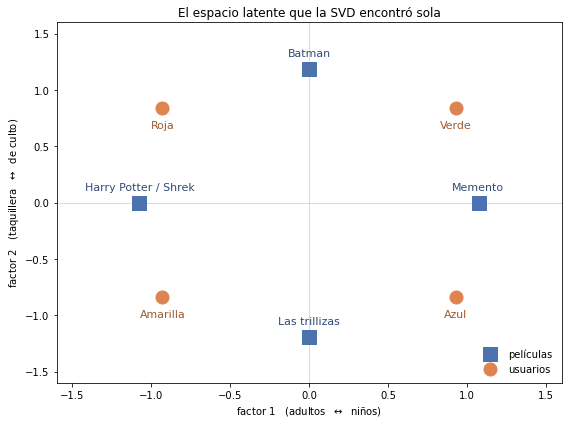

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
ax.axhline(0, color='0.85', lw=1, zorder=0)
ax.axvline(0, color='0.85', lw=1, zorder=0)

ax.scatter(Q[:, 0], Q[:, 1], s=170, marker='s', color='#4C72B0', label='películas', zorder=3)
ax.scatter(P[:, 0], P[:, 1], s=170, marker='o', color='#DD8452', label='usuarios',  zorder=3)

def etiquetar(coords, nombres, dy, color):
    """Junta en una sola etiqueta los puntos que caen en el mismo lugar."""
    juntos = {}
    for (x, y), t in zip(coords, nombres):
        juntos.setdefault((round(x, 2), round(y, 2)), []).append(t)
    for (x, y), ts in juntos.items():
        ax.annotate(' / '.join(ts), (x, y), xytext=(0, dy), textcoords='offset points',
                    ha='center', fontsize=11, color=color)

etiquetar(Q, peliculas,  12, '#2F4A75')
etiquetar(P, usuarios,  -20, '#9C5A2E')

ax.set_xlabel('factor 1   (adultos  $\\leftrightarrow$  niños)')
ax.set_ylabel('factor 2   (taquillera  $\\leftrightarrow$  de culto)')
ax.set_title('El espacio latente que la SVD encontró sola')
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

Compárenlo con la última figura que dibujamos a mano. Cada usuario quedó **rodeado de las películas que vio**, y lejos de las que no. Eso es lo que significa que el producto punto prediga la preferencia: si el vector del usuario y el de la película apuntan hacia el mismo lado, el producto es grande.

 **Harry Potter y Shrek quedaron exactamente en el mismo punto.** No es un error del gráfico. Sus columnas en la tabla son idénticas: las vieron las mismas dos personas y ninguna otra. Con esa información el modelo no tiene absolutamente ninguna forma de distinguirlas, y hace bien en no inventarse una diferencia. Con más usuarios se separarían.

Y acá está el pago de haber armado el espacio así: **para recomendar, basta con buscar los ítems más cercanos al usuario**, en el mismo gráfico.



Antes de seguir comparemos numéricamente el embedding que encontró la SVD con el que habíamos dibujado a mano.

In [10]:
from scipy.linalg import orthogonal_procrustes

# el embedding de las películas que pusimos a mano, leído de la figura colab3b
Q_mano = np.array([[ 0.9, -0.2],    # Harry Potter
                   [-1.0, -0.8],    # Las trillizas
                   [ 1.0, -1.0],    # Shrek
                   [ 1.0,  0.9],    # Batman
                   [-0.9,  1.0]])   # Memento

print('correlación de cada eje de la SVD con cada eje dibujado a mano:')
for j in range(2):
    for l in range(2):
        print(f'   factor {j+1} de la SVD  vs  eje {l+1} a mano : '
              f'{np.corrcoef(Q[:, j], Q_mano[:, l])[0, 1]:6.3f}')

# ¿y si le permitimos a la SVD girar sus ejes?
R, _ = orthogonal_procrustes(Q, Q_mano)
Q_rot = Q @ R
angulo = np.degrees(np.arctan2(R[1, 0], R[0, 0]))

print(f'\nmejor rotación posible: {angulo:.1f} grados')
print('correlación después de rotar:',
      [round(float(np.corrcoef(Q_rot[:, j], Q_mano[:, j])[0, 1]), 3) for j in range(2)])

correlación de cada eje de la SVD con cada eje dibujado a mano:
   factor 1 de la SVD  vs  eje 1 a mano : -0.739
   factor 1 de la SVD  vs  eje 2 a mano :  0.698
   factor 2 de la SVD  vs  eje 1 a mano :  0.673
   factor 2 de la SVD  vs  eje 2 a mano :  0.644

mejor rotación posible: 136.7 grados
correlación después de rotar: [0.999, 0.949]


Los ejes crudos se parecen apenas: en valor absoluto, las correlaciones van de **0,64 a 0,74**. Pero si le permitimos **girar y reflejar el plano unos 43 grados**, la coincidencia con nuestro dibujo pasa a ser de **0,999 y 0,949**.

La conclusión es la que hay que llevarse:

> **La SVD no recupera los ejes. Recupera el espacio.**

Y hay una razón algebraica exacta. Si $R$ es cualquier matriz ortogonal ($RR^\top = I$), entonces

$$
(P R)(Q R)^\top \;=\; P R R^\top Q^\top \;=\; P\,Q^\top .
$$

Girar los dos embeddings a la vez **no cambia ni una sola predicción**. Hay infinitas factorizaciones igual de buenas, y la SVD elige una de ellas: la que ordena los factores de mayor a menor importancia.

De ahí se siguen dos cosas prácticas:

- Es una **suerte**, no una garantía, que un factor tenga un nombre bonito como "adultos ↔ niños". Con datos reales lo habitual es que los primeros factores sean interpretables y los demás no.
- **Comparar el factor 1 de un modelo con el factor 1 de otro no tiene sentido.** Lo que se puede comparar son las predicciones.

## 6.4 De la factorización a la recomendación

Volvamos a las películas del principio de la sesión, en dos pasos: primero una versión más limpia de la tabla (`pelis.csv`), y después la tabla con la que veníamos trabajando.

### El caso limpio

Siete usuarios, cinco películas, y dos grupos que no se tocan: los cuatro primeros solo ven ciencia ficción, los tres últimos solo romance.

In [11]:
A_limpia = pd.read_csv('data/pelis.csv').set_index('Usuarios')
A_limpia.columns = A_limpia.columns.str.strip()

U, S, Vt = np.linalg.svd(A_limpia, full_matrices=False)
print('rango:', np.linalg.matrix_rank(A_limpia.to_numpy()))
print('valores singulares:', np.round(S, 2), '\n')

print('U  —  usuarios (2 primeros factores)')
print(pd.DataFrame(U[:, :2].round(2), index=A_limpia.index, columns=['concepto 1', 'concepto 2']))
print('\nV  —  películas (2 primeros factores)')
print(pd.DataFrame(Vt[:2, :].T.round(2), index=A_limpia.columns, columns=['concepto 1', 'concepto 2']))

rango: 2
valores singulares: [12.37  9.49  0.    0.    0.  ] 

U  —  usuarios (2 primeros factores)
          concepto 1  concepto 2
Usuarios                        
Juan           -0.14        0.00
Jose           -0.42        0.00
Lucas          -0.56        0.00
Ana            -0.70        0.00
Martina         0.00       -0.60
Ines            0.00       -0.75
Daniel          0.00       -0.30

V  —  películas (2 primeros factores)
            concepto 1  concepto 2
Matrix           -0.58       -0.00
Alien            -0.58       -0.00
Star Wars        -0.58       -0.00
Casablanca       -0.00       -0.71
Titanic          -0.00       -0.71


Los dos conceptos salen **perfectamente separados**, sin que nadie los nombrara:

- El **concepto 1** carga sobre Matrix, Alien y Star Wars, y sobre Juan, José, Lucas y Ana. Es **ciencia ficción**.
- El **concepto 2** carga sobre Casablanca y Titanic, y sobre Martina, Inés y Daniel. Es **romance**.
- Los ceros son exactos: Juan no participa en absoluto del concepto romance.

Que las cargas salgan **negativas** no significa nada: es el signo arbitrario del que hablábamos recién. Si multiplicáramos por $-1$ la columna de $U$ y la de $V$ a la vez, las predicciones serían idénticas.

Y $\Sigma$ dice cuánto pesa cada uno: **12,37 para ciencia ficción y 9,49 para romance**. La ciencia ficción es el concepto más fuerte porque los datos traen más información sobre esas películas y sobre la gente que las ve.

Fíjense también en Juan: su valor en la primera columna de $U$ es $-0{,}14$, **más chico que el de los demás usuarios de ciencia ficción**. No es que le guste menos el género; es que califica más bajo que todos ($1,1,1$ contra el $5,5,5$ de Ana). La primera columna de $U$ —y por lo tanto de $P$— captura la intensidad, que es justamente lo que el coseno del § 4 no podía distinguir.

### El caso realista

En la vida real los conceptos no salen tan limpios. Cambiemos apenas la tabla: que Martina y Daniel hayan visto Alien, aunque no les haya gustado demasiado. Es la tabla `A` con la que veníamos trabajando.

In [12]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)

varianza = pd.DataFrame({
    'valor singular': S.round(3),
    'varianza explicada (%)': (S**2 / np.sum(S**2) * 100).round(2),
    'acumulada (%)': (np.cumsum(S**2) / np.sum(S**2) * 100).round(2),
}, index=[f'concepto {j+1}' for j in range(len(S))])

print('rango:', np.linalg.matrix_rank(A.to_numpy()))
varianza

rango: 3


,valor singular,varianza explicada (%),acumulada (%)
concepto 1,12.481,62.81,62.81
concepto 2,9.509,36.46,99.27
concepto 3,1.346,0.73,100.00
concepto 4,0.000,0.00,100.00
concepto 5,0.000,0.00,100.00


El rango ahora es 3, así que hay un tercer concepto. Pero pesa muy poco: los dos primeros ya explican el **99,27%** de la varianza.

Y ese tercer concepto es difícil de nombrar. No es un defecto del ejemplo — es lo que anticipamos en el § 6.3: solo los primeros factores tienden a ser interpretables. Como pesa 1,35 contra 12,48 y 9,51, lo descartamos.

Nos quedamos con $K=2$. **Y acá es donde la reconstrucción deja de ser un ejercicio de álgebra y se vuelve una predicción.**

In [13]:
K = 2
P_u = U[:, :K] * np.sqrt(S[:K])          # embedding de los usuarios
Q_i = Vt[:K, :].T * np.sqrt(S[:K])       # embedding de las películas

A_hat = pd.DataFrame(P_u @ Q_i.T, index=A.index, columns=A.columns).round(2)

print('observado');   print(A)
print('\nreconstruido con K = 2'); print(A_hat)

observado
          Matrix  Alien  Star Wars  Casablanca  Titanic
Usuarios                                               
Juan           1      1          1           0        0
Jose           3      3          3           0        0
Lucas          4      4          4           0        0
Ana            5      5          5           0        0
Martina        0      2          0           4        4
Ines           0      0          0           5        5
Daniel         0      1          0           2        2

reconstruido con K = 2
          Matrix  Alien  Star Wars  Casablanca  Titanic
Usuarios                                               
Juan        0.99   1.01       0.99       -0.00    -0.00
Jose        2.98   3.04       2.98       -0.00    -0.00
Lucas       3.98   4.05       3.98       -0.01    -0.01
Ana         4.97   5.06       4.97       -0.01    -0.01
Martina     0.36   1.29       0.36        4.08     4.08
Ines       -0.37   0.73      -0.37        4.92     4.92
Daniel      0.

Comparen las dos tablas celda por celda. Cuatro cosas.

**1. Donde había un dato, la reconstrucción lo respeta.** Ana sigue en 4,97 / 5,06 / 4,97.

**2. Donde el dato desentonaba, el modelo lo suaviza.** Martina le había puesto **2** a Alien, y el modelo reconstruye **1,29**. Con solo dos factores no puede representar ese 2: el perfil de Martina es romántico, y Alien es lo único de ciencia ficción que vio. La reconstrucción tira ese valor hacia abajo, hacia lo que el resto de su fila sugiere. Truncar es, precisamente, decidir qué detalles no vale la pena conservar.

**3. Donde había un cero, ahora hay una predicción.** Martina nunca vio Matrix, y el modelo le asigna **0,36**. Y sobre todo, **la celda de Inés en `Matrix`, donde el coseno del § 4 devolvía `NaN`, ahora tiene un número: −0,37**. El motor ya no se rinde: con solo dos factores puede opinar sobre cualquier par usuario-película del catálogo. Esa es la ventaja decisiva de la factorización sobre los vecinos, y la razón por la que se usa en catálogos dispersos.

**4. Y ese número es −0,37.** Una calificación negativa, que no existe.

Esta última es la advertencia importante. La SVD **no sabe nada del dominio**: no sabe que las calificaciones van de 1 a 5, ni que no pueden ser negativas. Los sistemas de producción usan por eso variantes con restricciones (factorización no negativa, o mínimos cuadrados alternados que solo miran las celdas observadas). La SVD cruda es el punto de partida conceptual.

In [ ]:
def top_n_svd(usuario, n=2):
    """Recomienda las películas mejor puntuadas por el modelo entre las que el usuario no vio."""
    no_vistas = A.columns[A.loc[usuario] == 0]
    return A_hat.loc[usuario, no_vistas].sort_values(ascending=False).head(n)

for u in ['Juan', 'Ines']:
    print(f'{u}:'); print(top_n_svd(u), '\n')

Vale la pena leer estas dos listas con cuidado, porque dicen más de lo que parece.

**A Juan el modelo le da 0,0 en las dos películas románticas.** No es que falle: está diciendo, correctamente, que no tiene ninguna razón para empujarle romance a alguien cuyo perfil es puramente de ciencia ficción. Un recomendador que sabe cuándo *no* recomendar es mejor que uno que siempre llena la lista.

**A Inés le ofrece Alien (0,73) por encima de Matrix (−0,37).** Y esto es lo interesante: Inés nunca vio ninguna película de ciencia ficción, así que el motor de vecinos del § 4 no podía decir nada. Pero Alien es la única del género que también vieron Martina y Daniel, dos de los tres usuarios románticos. La SVD detectó que Alien es el **puente** entre los dos mundos y por eso la pone primera. Ningún ser humano le señaló eso: salió de dos factores estimados sobre treinta y cinco números.

# 7. Motor 5: reglas de asociación

Los cuatro motores anteriores parten de una matriz de calificaciones. El quinto cambia de objeto: en vez de calificaciones mira **canastas**, es decir, conjuntos de cosas que aparecen juntas.

Viene del **análisis de canasta de compra**, y la pregunta que responde es distinta a la de los otros: ya no *"¿qué le gustaría a este usuario?"* sino *"¿qué cosas se llevan juntas?"*.

## Un ejemplo de supermercado

Cinco transacciones:

| # | Canasta |
|---|---|
| 1 | {Pan, Leche, Huevos} |
| 2 | {Pan, Mantequilla} |
| 3 | {Pan, Leche, Mantequilla, Huevos} |
| 4 | {Leche, Mantequilla} |
| 5 | {Pan, Leche} |

Una **regla de asociación** $X \rightarrow Y$ se lee "quien lleva $X$ también lleva $Y$", y se evalúa con tres números:

$$
\text{soporte}(X \rightarrow Y) = \frac{\#\{\text{canastas con } X \text{ y } Y\}}{\#\text{canastas}}
\qquad \text{ ¿qué tan frecuente es?}
$$

$$
\text{confianza}(X \rightarrow Y) = \frac{\text{soporte}(X \cup Y)}{\text{soporte}(X)}
\qquad \text{ de los que llevan } X, \text{ ¿qué fracción lleva } Y?
$$

$$
\text{lift}(X \rightarrow Y) = \frac{\text{confianza}(X \rightarrow Y)}{\text{soporte}(Y)}
\qquad \text{ ¿cuánto mejor que el azar?}
$$

El **lift** es el que decide si la regla sirve. Si vale 1, $X$ y $Y$ aparecen juntos exactamente lo que se esperaría si fueran independientes: la regla no informa nada. Solo por encima de 1 hay algo que aprovechar.

In [ ]:
from itertools import permutations

canastas = [{'Pan', 'Leche', 'Huevos'},
            {'Pan', 'Mantequilla'},
            {'Pan', 'Leche', 'Mantequilla', 'Huevos'},
            {'Leche', 'Mantequilla'},
            {'Pan', 'Leche'}]

def soporte(conjunto):
    return sum(1 for c in canastas if conjunto <= c) / len(canastas)

filas = []
for x, y in permutations(sorted(set().union(*canastas)), 2):
    s = soporte({x, y})
    if s >= 0.4:
        conf = s / soporte({x})
        filas.append([f'{x} -> {y}', s, conf, conf / soporte({y})])

pd.DataFrame(filas, columns=['regla', 'soporte', 'confianza', 'lift']) \
  .sort_values('soporte', ascending=False).round(2).reset_index(drop=True)

Ordenamos por soporte, que es lo que uno miraría primero. Y la tabla desarma esa intuición.

**`Leche -> Pan` es la regla más frecuente (soporte 0,60) y una de las más confiables (0,75). Y su lift es 0,94.** Es decir: está **por debajo** de 1. Pan y Leche aparecen juntos *menos* de lo que aparecerían por puro azar. La regla parece fuerte y no sirve para nada — lo único que dice es que Pan y Leche son, cada uno por su lado, muy comunes.

**`Huevos -> Leche` tiene menos soporte (0,40), pero confianza 1,00 y lift 1,25.** Esa sí informa: quien lleva huevos lleva leche siempre, y eso no se explica por lo común que es la leche.

Si hubiéramos ordenado por soporte y cortado ahí, nos habríamos quedado justo con la regla que no sirve.

> Es la pregunta del **Paso 6 del Taller 5**: *¿la confianza y el lift dicen lo mismo sobre la utilidad de una regla?* No, y con cinco transacciones ya se ve por qué.

## El principio del algoritmo Apriori

Con los 167 productos del caso que viene hay más de 13.000 pares posibles, y muchísimos más tríos. Contar todos los subconjuntos es inviable. El algoritmo **Apriori** poda el espacio de búsqueda con una sola observación:

> **Si un conjunto no es frecuente, ninguno de sus superconjuntos puede serlo.**

Si {Pan, Leche} aparece en menos del 1% de las canastas, entonces {Pan, Leche, Huevos} aparece todavía menos, y no hace falta ni contarlo. El algoritmo va armando conjuntos de tamaño creciente y descarta ramas enteras apenas caen bajo el soporte mínimo.

## Un caso con datos reales

Dos años de transacciones de un supermercado, 2014 y 2015.

In [ ]:
compras = pd.read_csv('data/Groceries_dataset.csv')
compras['transaccion'] = compras['Member_number'].astype(str) + '_' + compras['Date'].astype(str)
compras.head()

In [ ]:
print('socios       :', compras['Member_number'].nunique())
print('transacciones:', compras['transaccion'].nunique())
print('productos    :', compras['itemDescription'].nunique())
print('\nlos 5 productos más vendidos:')
print(compras['itemDescription'].value_counts().head())

In [ ]:
# una fila por transacción, una columna por producto, True si el producto estuvo en la canasta.
# El análisis de canasta no mira cuántas unidades se llevaron, solo si el producto estuvo o no.
canasta = pd.crosstab(compras['transaccion'], compras['itemDescription']) > 0

print('dimensión :', canasta.shape)
print('densidad  : %.2f%%' % (canasta.to_numpy().mean() * 100))
print('productos por transacción (media): %.2f' % canasta.sum(axis=1).mean())
canasta.iloc[:5, :6]

La matriz está llena en un **1,5%**, y cada canasta tiene en promedio **2,5 productos**. Es el mismo problema de dispersión de siempre, y acá determina directamente el soporte mínimo que podemos pedir: con canastas tan chicas, ningún par va a aparecer en el 5% de las transacciones. Usamos `min_support=0.001` y nos limitamos a reglas de **dos productos** (`max_len=2`), que es lo que el Taller 5 les recomienda para que el cómputo no se dispare.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frecuentes = apriori(canasta, min_support=0.001, use_colnames=True, max_len=2)
reglas = association_rules(frecuentes, metric='lift', min_threshold=1)

# nos quedamos con las reglas de un producto a un producto, y las ordenamos por lift
reglas = reglas[reglas['antecedents'].map(len) == 1].copy()
reglas['antecedente'] = reglas['antecedents'].map(lambda s: list(s)[0])
reglas['consecuente'] = reglas['consequents'].map(lambda s: list(s)[0])

reglas.sort_values('lift', ascending=False)[
    ['antecedente', 'consecuente', 'support', 'confidence', 'lift']
].head(10).round(4).reset_index(drop=True)

Dos lecturas

**La primera: no aparece `whole milk`.** Es el producto más vendido del supermercado por lejos, y no está en ninguna de las diez mejores reglas. Es exactamente lo contrario de lo que hacía el motor de popularidad del § 3. El lift **castiga** lo popular: como la leche está en todas partes, aparecer junto a ella no es informativo.

**La segunda: estas reglas tienen lift alto y confianza bajísima.** `citrus fruit -> specialty chocolate` tiene lift 1,65, pero su confianza es 2,6%: de cada 100 personas que llevan cítricos, menos de 3 llevan ese chocolate. La asociación es real y es inútil como recomendación por sí sola.

Y de ahí sale la advertencia operativa: **subir el soporte mínimo mata la cola del catálogo**. Con un umbral más alto solo sobreviven reglas entre productos muy vendidos, que son justamente las que menos falta hace descubrir. 

In [ ]:
def recomendar_por_reglas(producto, n=3):
    r = reglas[reglas['antecedente'] == producto]
    return r.sort_values('lift', ascending=False)[['consecuente', 'confidence', 'lift']].head(n).round(4)

print('Alguien acaba de poner "sausage" en el carrito. ¿Qué le sugerimos?')
recomendar_por_reglas('sausage')

# 8. Los cinco motores de recomendación

Volvamos al mapa del § 1, ahora con la columna que faltaba.

| | Motor | La pregunta que responde | **Dónde falla** |
|---|---|---|---|
| 1 | Popularidad simple | ¿Qué ve mucha gente? | Le da **el mismo orden a todos**. Y "más visto" no es "mejor": Alien era la más vista y la peor calificada |
| 2 | Popularidad ponderada | ¿Qué ve mucha gente y le gusta? | Sigue sin ser personal. Y premia a lo que tiene pocas calificaciones muy altas |
| 3 | Similitud de coseno | ¿Qué ven los que se parecen a este usuario? | **Devuelve `NaN`** cuando ningún vecino parecido vio el ítem. Con matrices dispersas, casi siempre. Además ignora la intensidad: Juan y Ana le parecen idénticos |
| 4 | Factores latentes (SVD) | ¿Qué dimensiones de gusto explican la tabla? | Siempre da un número, pero puede ser **absurdo** (−0,37 estrellas). Los factores no son únicos ni necesariamente interpretables. Hay que elegir $K$ |
| 5 | Reglas de asociación | ¿Qué cosas se consumen juntas? | No es personal: la regla es la misma para todos los que llevan el producto. Y el soporte mínimo **borra la cola del catálogo** |

Ninguno gana en todo.

## Cómo se evalúa un sistema de recomendación

Todo lo anterior produce listas. Falta lo más difícil: decidir si una lista es buena. Hay dos familias de respuestas.

### Evaluación offline

Es la que ya conocen del aprendizaje supervisado: se parte la base en entrenamiento y prueba, se esconden calificaciones conocidas, se predicen y se mide el error. Con calificaciones numéricas, la métrica habitual es la raíz del error cuadrático medio (RMSE); con listas, se usan métricas de ranking como la precisión en los primeros $k$ resultados (ese $k$ no tiene nada que ver con el $K$ de factores del § 6).

Es barata y reproducible. Y tiene un límite serio: **solo puede evaluar aciertos sobre lo que el usuario ya consumió**. Un motor que recomienda algo que al usuario le habría encantado, pero que nunca escuchó, cuenta como error. La evaluación offline premia sistemáticamente a los motores conservadores, que es justo lo contrario de lo que se busca cuando se quiere ayudar a descubrir.

### Evaluación online

Consiste en observar las interacciones reales de los usuarios con el sistema. La técnica más común es la **prueba A/B**: dos versiones del recomendador funcionando a la vez sobre grupos de usuarios asignados al azar.

<div style="max-width:500px"><img src = "figs/AB.jpg" /></div>

La ventaja es que evalúa el sistema mientras los usuarios efectivamente lo usan, y por lo tanto mide lo que de verdad importa. La dificultad es que requiere **estimación de parámetros causales**: hay que asegurarse de que la diferencia entre los dos grupos se debe al recomendador y no a otra cosa.

<div style="max-width:500px"><img src = "figs/BING.png" /></div>

En esta situación las métricas offline como el RMSE no alcanzan. Lo que interesa es el objetivo global del sistema: la **retención** de los usuarios.

# Referencias

- Leskovec, J., Rajaraman, A., & Ullman, J. D. (2020). *Mining of Massive Datasets* (3.ª ed.), capítulo 11. Cambridge University Press. — De aquí salen los ejemplos de `pelis.csv` y `pelis2.csv` (figuras 11.6 a 11.9) y la interpretación de los conceptos latentes.
- Google (2022). *Machine Learning Crash Course — Recommendation Systems*. https://developers.google.com/machine-learning/recommendation — De aquí salen las figuras del ejemplo de SlowFlow y la presentación de los embeddings.
- Eckart, C., & Young, G. (1936). The approximation of one matrix by another of lower rank. *Psychometrika*, 1(3), 211–218. — El teorema que justifica usar la SVD truncada.
- Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer*, 42(8), 30–37. — El artículo de referencia sobre factores latentes en recomendación, escrito por el equipo ganador del Premio Netflix.
- McKinsey & Company (2013). *How retailers can keep up with consumers*. https://www.mckinsey.com/industries/retail/our-insights/how-retailers-can-keep-up-with-consumers
- Kohavi, R., Tang, D., & Xu, Y. (2020). *Trustworthy Online Controlled Experiments*. Cambridge University Press. — Sobre pruebas A/B.
- Bytepawn. *Experimentation lessons from Google, Bing, Netflix and Alibaba*. https://bytepawn.com/experimentation-lessons-google-bing-netflix-alibaba.html
- Groceries dataset, publicado en Kaggle a partir del conjunto `Groceries` del paquete `arules` de R.